## Data Preprocessing and cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")

df.head()
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

df["age"] = (df["age"] / 365.25).round().astype(int)
df.rename(columns={"age": "age_years"}, inplace=True)

df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,48,1,156,56.0,100,60,1,1,0,0,0,0


# Removing Duplicates

In [3]:
duplicates = df.duplicated().sum()
print(duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(df.shape)

3821
(66179, 12)


droping impossible blood pressure

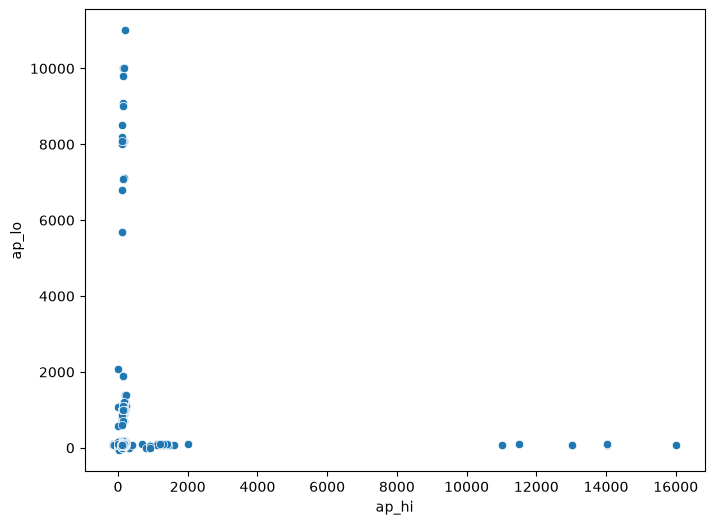

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="ap_hi", y="ap_lo", data=df)
plt.show()

ap_hi > ap_lo, ap_hi between 50 and 250, ap_lo between 30 and 150

In [9]:
# len(df)
df = df[df["ap_hi"] > df["ap_lo"]]
# len(df)

df = df[(df["ap_hi"] >= 50) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 30) & (df["ap_lo"] <= 150)]
len(df)

64853

visualizing the graph again after cleaning

<Axes: xlabel='ap_hi', ylabel='ap_lo'>

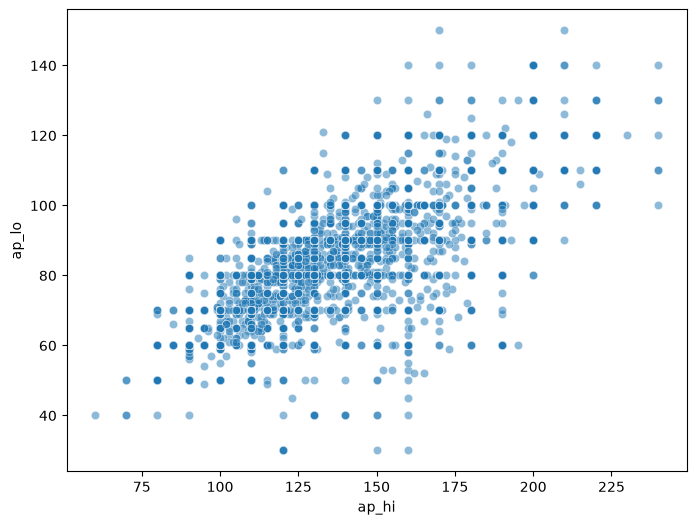

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="ap_hi", y="ap_lo", data=df, alpha=0.5)

# Handling outliers like height and weight

There were many people with height around 50 cm and many light weights too. they are not practically possible

<Axes: xlabel='cardio', ylabel='height'>

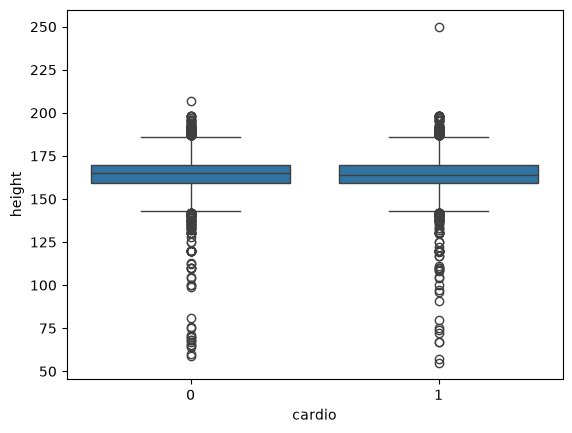

In [60]:
sns.boxplot(x='cardio', y='height', data=df)

<Axes: xlabel='cardio', ylabel='weight'>

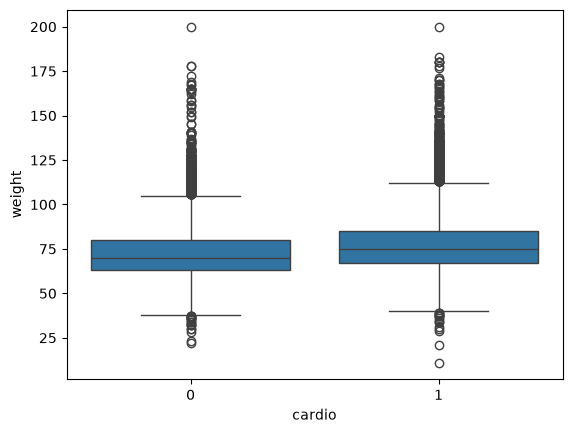

In [62]:
sns.boxplot(x='cardio', y='weight', data=df)

 Interquartile Range IQR method to detect and remove these outliers.
Keep data within Q1 - 1.5 * IQR and Q3 + 1.5 * IQR.

In [64]:
def remove_outlier_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("before", len(df))
df = remove_outlier_iqr(df, "height")
df = remove_outlier_iqr(df, "weight")
print("after", len(df))

before 64853
after 62665


<Axes: xlabel='height'>

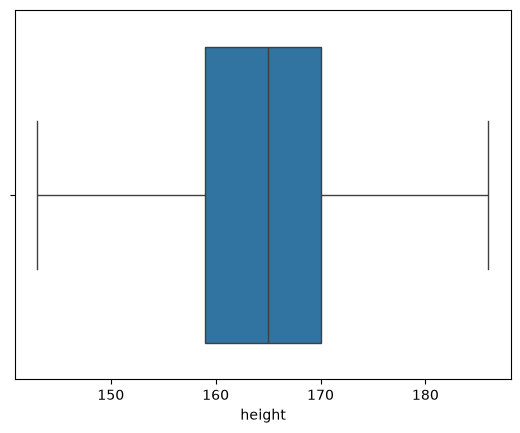

In [65]:
sns.boxplot(x=df['height'])

<Axes: xlabel='weight'>

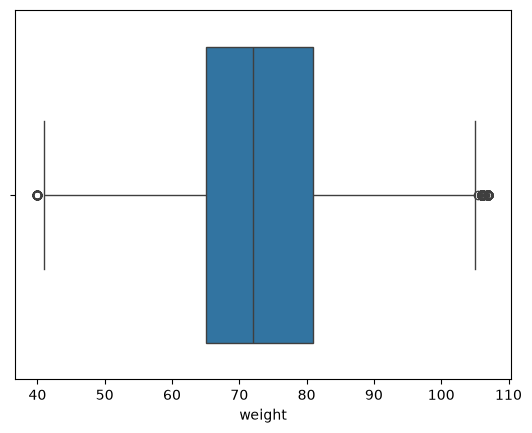

In [66]:
sns.boxplot(x=df['weight'])

In [68]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['bmi'].head()

0    21.967120
1    34.927679
2    23.507805
3    28.710479
4    23.011177
Name: bmi, dtype: float64

converting categorical features

In [70]:
df = pd.get_dummies(df, columns=["cholesterol", "gluc"], prefix=["chol", "gluc"])
bool_cols = [col for col in df.columns if "chol_" in col or "gluc_" in col]
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,bmi,chol_1,chol_2,chol_3,gluc_1,gluc_2,gluc_3
0,50,2,168,62.0,110,80,0,0,1,0,21.967120,1,0,0,1,0,0
1,55,1,156,85.0,140,90,0,0,1,1,34.927679,0,0,1,1,0,0
2,52,1,165,64.0,130,70,0,0,0,1,23.507805,0,0,1,1,0,0
3,48,2,169,82.0,150,100,0,0,1,1,28.710479,1,0,0,1,0,0
4,48,1,156,56.0,100,60,0,0,0,0,23.011177,1,0,0,1,0,0


# Splitting data for training and testing

In [71]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(50132, 16)
(12533, 16)


Feature scalling

In [72]:
# age_years, height, weight, ap_hi, ap_lo, bmi

scale_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.fit_transform(X_test[scale_cols])

X_train[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,50132.0,-1.841838e-16,1.00001,-3.419609,-0.778094,0.102411,0.689414,1.716670
height,50132.0,-1.417344e-16,1.00001,-2.775353,-0.689454,-0.037611,0.744601,2.830499
weight,50132.0,7.375857e-16,1.00001,-2.655109,-0.660886,-0.102503,0.615417,2.689409
ap_hi,50132.0,-2.653267e-16,1.00001,-3.962764,-0.397859,-0.397859,0.790443,6.731952
ap_lo,50132.0,1.237341e-16,1.00001,-5.351653,-0.124494,-0.124494,0.920938,7.193529
bmi,50132.0,-8.560756e-17,1.00001,-2.938762,-0.713591,-0.171420,0.611964,4.513053


In [ ]:
train_data = X_train.copy()
train_data['cardio'] = y_train

test_data = X_test.copy()
test_data['cardio'] = y_test

train_data.to_csv('./data/train.csv', index=False)
test_data.to_csv('./data/test.csv', index=False)